In [1]:
import kagglehub
path = kagglehub.dataset_download("elmadafri/the-wildfire-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/the-wildfire-dataset


In [2]:
#importing necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Flatten, Dense,Dropout,Input

In [3]:
#To ensure the GPU is prsent
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
  tf.config.experimental.set_memory_growth(physical_devices[0], True)
  print("GPU is available")
else:
  print("GPU is not available")

GPU is available


In [4]:
# Load the dataset
train_dir = '/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/train'
val_dir = '/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/val'
test_dir = '/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/test'

In [5]:
#list all the classes
classes=os.listdir(test_dir)
num_classes=len(classes)

#display the class names
print(f'Number of classes: {num_classes}')
print(f'Classes: {classes}')

Number of classes: 2
Classes: ['nofire', 'fire']


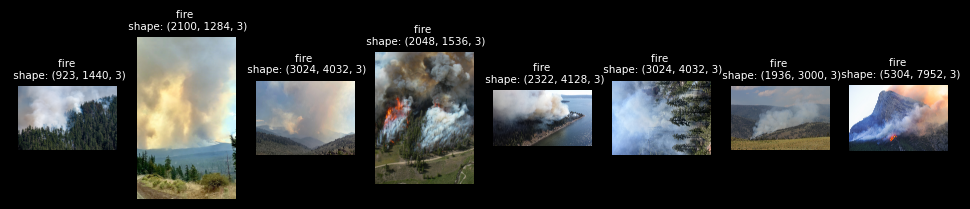

In [22]:
#visulize the images  of fire
plt.figure(figsize=(12,10))
for i in range(8):
  class_path=os.path.join(train_dir,classes[1])
  img_name=os.listdir(class_path)[i]
  img_path=os.path.join(class_path,img_name)
  img=plt.imread(img_path)

  plt.subplot(1,8,i+1)
  plt.imshow(img)
  plt.title(f'{classes[1]} \n shape: {img.shape}', fontsize=7.5)

  plt.axis('off')
plt.show()

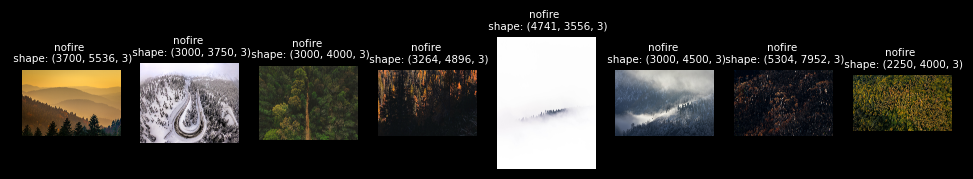

In [27]:
#visulization of no fire
plt.figure(figsize=(12,10))
for i in range(8):
  class_path=os.path.join(train_dir,classes[0])
  img_name=os.listdir(class_path)[i]
  img_path=os.path.join(class_path,img_name)
  img=plt.imread(img_path)
  plt.subplot(1,8,i+1)
  plt.imshow(img)
  plt.title(f'{classes[0]} \n shape: {img.shape}', fontsize=7.5)
  plt.axis('off')
plt.show()

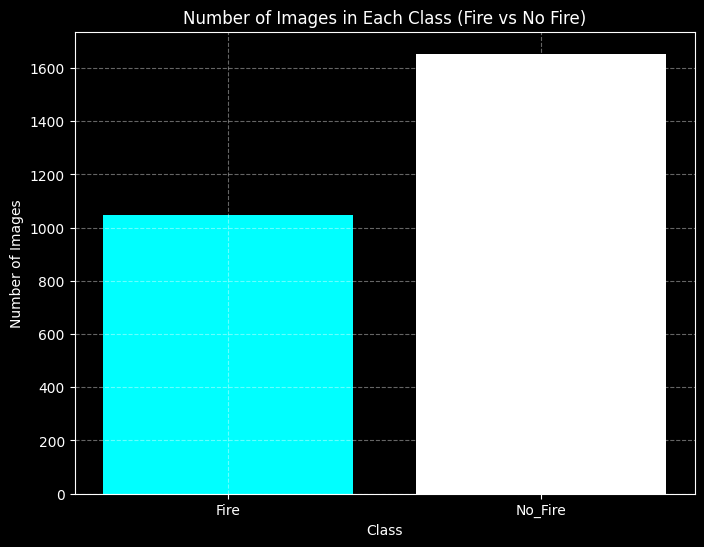

In [8]:
plt.style.use('dark_background')
base_dir = '/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version'
splits = ['train', 'val', 'test']
class_counts = {'Fire': 1, 'No_Fire': 0}

for split in splits:
    split_dir = os.path.join(base_dir, split)
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        count = len(os.listdir(cls_path))
        if cls.lower() == 'fire':
            class_counts['Fire'] += count
        elif cls.lower() == 'nofire':
            class_counts['No_Fire'] += count
plt.figure(figsize=(8,6))
plt.bar(class_counts.keys(), class_counts.values(), color=['cyan', 'white'])
plt.title('Number of Images in Each Class (Fire vs No Fire)')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [10]:
IMG_HEIGHT, IMG_WIDTH = 150, 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)



train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle = True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)



Found 1887 images belonging to 2 classes.
Found 402 images belonging to 2 classes.
Found 410 images belonging to 2 classes.


In [23]:
class_mapping=train_generator.class_indices
print(class_mapping)
class_names=list(class_mapping.keys())
print("class names:",class_names)

{'fire': 0, 'nofire': 1}
class names: ['fire', 'nofire']


In [12]:
print("Before training the model .\n")
print(f"Training on {train_generator.samples} images, validating on {val_generator.samples} images.")
print(f"Image size: {IMG_HEIGHT}x{IMG_WIDTH}, Batch size: {BATCH_SIZE}")
print(f"Number of classes: {train_generator.num_classes}")



Before training the model .

Training on 1887 images, validating on 402 images.
Image size: 150x150, Batch size: 32
Number of classes: 2


In [29]:
model= Sequential([
    Input(shape=(IMG_HEIGHT,IMG_WIDTH,3)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])
